<h2 align="center">Time Series Forecasting on Monthly Average Temperature Data Across India from 1901 to 2017</h2>

## Name: SEANG Vutha
## ID: M080405

### India Monthly Temperature Forecasting
### **Dataset:** Temperatures-of-india (Kaggle) 1901–2017
`` "India's temperature record spans over a century of monthly observations, capturing seasonal monsoon cycles, long-term warming trends, and the fingerprint of climate change on the subcontinent." ``

In [4]:
%pip install kagglehub

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install plotly

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


> ## 1. Loading Dataset

In [6]:
import boto3
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.metrics import mean_absolute_error, mean_squared_error
import plotly.io as pio
import warnings
warnings.filterwarnings('ignore')

In [7]:
pio.renderers.default = "vscode"

s3 = boto3.client('s3', region_name='us-east-1')
bucket_name = 'vutha-india-temperature-capstone'
key = 'raw/India_temperatures.csv'

obj = s3.get_object(Bucket=bucket_name, Key=key)
df_raw = pd.read_csv(obj['Body'])

In [8]:
df_raw.tail()

,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,JAN-FEB,MAR-MAY,JUN-SEP,OCT-DEC
112,2013,24.56,26.59,30.62,32.66,34.46,32.44,31.07,30.76,31.04,30.27,27.83,25.37,29.81,25.58,32.58,31.33,27.83
113,2014,23.83,25.97,28.95,32.74,33.77,34.15,31.85,31.32,30.68,30.29,28.05,25.08,29.72,24.90,31.82,32.00,27.81
114,2015,24.58,26.89,29.07,31.87,34.09,32.48,31.88,31.52,31.55,31.04,28.10,25.67,29.90,25.74,31.68,31.87,28.27
115,2016,26.94,29.72,32.62,35.38,35.72,34.03,31.64,31.79,31.66,31.98,30.11,28.01,31.63,28.33,34.57,32.28,30.03
116,2017,26.45,29.46,31.60,34.95,35.84,33.82,31.88,31.72,32.22,32.29,29.60,27.18,31.42,27.95,34.13,32.41,29.69


In [9]:
df_raw.shape

(117, 18)

####  The dataset contains monthly average temperatures across India from **1901 to 2017**, originally in **wide format**  where each row represents one year and each column represents  one month from January to December 

> ### 1.1 Data Transformation

- Column Cleanup: Removed all aggregated columns (ANNUAL and JAN–FEB) to eliminate redundant data.
- Data Melting: Reshaped the 12 monthly columns into a single TEMPERATURE column using pandas melt (), creating one row per month.
- Categorical Ordering: Month names were encoded as an ordered Categorical (Jan–Dec) before sorting to ensure correct temporal alignment.
- Datetime Indexing: Year and month were combined into a DatetimeIndex with monthly-start frequency (MS), producing the chronological sequence required by all forecasting models.


In [10]:
df_melted = df_raw.melt(
    id_vars=['YEAR'],
    value_vars=['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC'],
    var_name='MONTH', value_name='TEMPERATURE'
)
month_order = ['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC']
df_melted['MONTH'] = pd.Categorical(df_melted['MONTH'], categories=month_order, ordered=True)
df_melted = df_melted.sort_values(['YEAR','MONTH']).reset_index(drop=True)
df_melted['DATE'] = df_melted['MONTH'].astype(str) + '-' + df_melted['YEAR'].astype(str)

In [11]:
df = df_melted[['DATE','TEMPERATURE']].copy()
df['DATE'] = pd.to_datetime(df['DATE'], format='%b-%Y')
df.set_index('DATE', inplace=True)
df.index.name = 'Date'
df = df.sort_index()
df = df.asfreq('MS') 
df.dropna(inplace=True)

print(f"Shape  : {df.shape}")
print(f"Period : {df.index[0].strftime('%b %Y')} to {df.index[-1].strftime('%b %Y')}")
print(f"Missing Value : {df.isnull().sum().values[0]}")
df.head(12)

Shape  : (1404, 1)
Period : Jan 1901 to Dec 2017
Missing Value : 0


,TEMPERATURE
Date,
1901-01-01,22.40
1901-02-01,24.14
1901-03-01,29.07
1901-04-01,31.91
1901-05-01,33.41
1901-06-01,33.18
1901-07-01,31.21
1901-08-01,30.39
1901-09-01,30.47


> ## 2. Exploratory Data Analysis (EDA)

> ### 2.1 Summary Statistics

In [12]:
print("SUMMARY STATISTICS")
print(df.describe().round())
print(f"\nTotal records: {len(df)}")
print(f"Date range: {df.index[0].strftime('%b %Y')} to {df.index[-1].strftime('%b %Y')}")
print(f"Missing values: {df.isnull().sum().values[0]}")

SUMMARY STATISTICS
       TEMPERATURE
count       1404.0
mean          29.0
std            3.0
min           22.0
25%           27.0
50%           30.0
75%           31.0
max           36.0

Total records: 1404
Date range: Jan 1901 to Dec 2017
Missing values: 0


After transformation, descriptive statistical analysis was performed on the continuous TEMPERATURE series covering the full 117-year period (January 1901 to December 2017).
- The dataset contains a total of 1,404 monthly records with 0 missing values, ensuring a complete and uninterrupted chronological timeline for modeling.
- The monthly average temperature is 29.0°C, with a standard deviation of 3.0°C, indicating stable seasonal fluctuations over time.
- The recorded temperatures range from a minimum of 22.0°C to a maximum of 36.0°C.
- Distribution (Percentiles): * 25% of the months recorded temperatures below 27.0°C.
- The median (50%) monthly temperature stands at 30.0°C.
- 75% of the records fall below 31.0°C, showing that the data is slightly left-skewed due to prolonged warmer months.

> ### 2.2 Temperature Time Series Plot

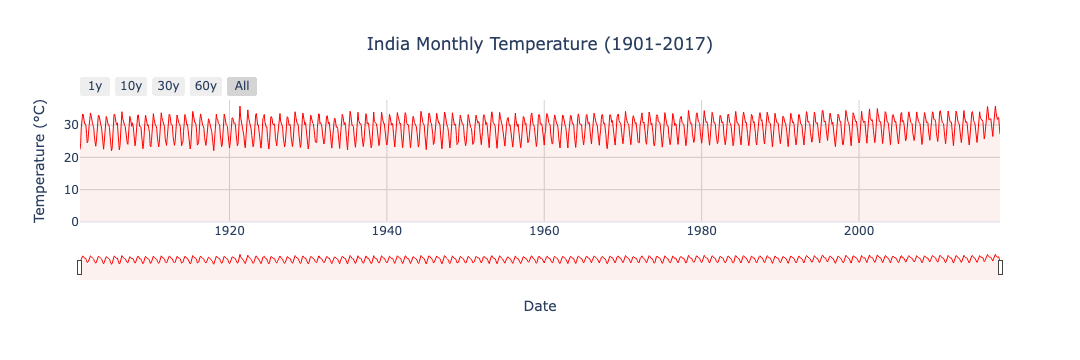

In [13]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df.index, y=df['TEMPERATURE'],
    mode='lines', name='Temperature',
    line=dict(color='Red', width=1),
    fill='tozeroy', fillcolor='rgba(231,76,60,0.08)',
))
fig.update_layout(
    title={'text': 'India Monthly Temperature (1901-2017)','x': 0.5},
    xaxis_title='Date', yaxis_title='Temperature (°C)',
    template='plotly_white', paper_bgcolor='white', plot_bgcolor='white',
)
fig.update_xaxes(
    showgrid=True, gridcolor='lightgray', rangeslider_visible=True,
    rangeselector=dict(buttons=list([
        dict(count=1,  label="1y",  step="year", stepmode="backward"),
        dict(count=10,  label="10y",  step="year", stepmode="backward"),
        dict(count=30,  label="30y",  step="year", stepmode="backward"),
        dict(count=60,  label="60y",  step="year", stepmode="backward"),
        dict(step="all", label="All")
    ]))
)
fig.update_yaxes(showgrid=True, gridcolor='lightgray')
fig.show()

This time series show us about 

-  Strong Seasonality: The regular up and down repeating every 12 months clearly shows India's annual temperature 
-  Long-term Trend: A slight **upward trend** is visible  from 1901 to 2017, consistent with global warming.temperatures in the 2000s appear slightly higher than in the early year.

-  Stable Variance: we don't  need for log transformation

These features confirm: **Trend + Seasonality + Stochastic component** structure, supporting the use  of SARIMA and Harmonic Regression models.

> ### 2.3 Seasonal Decomposition

In [14]:
%pip install statsmodels


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


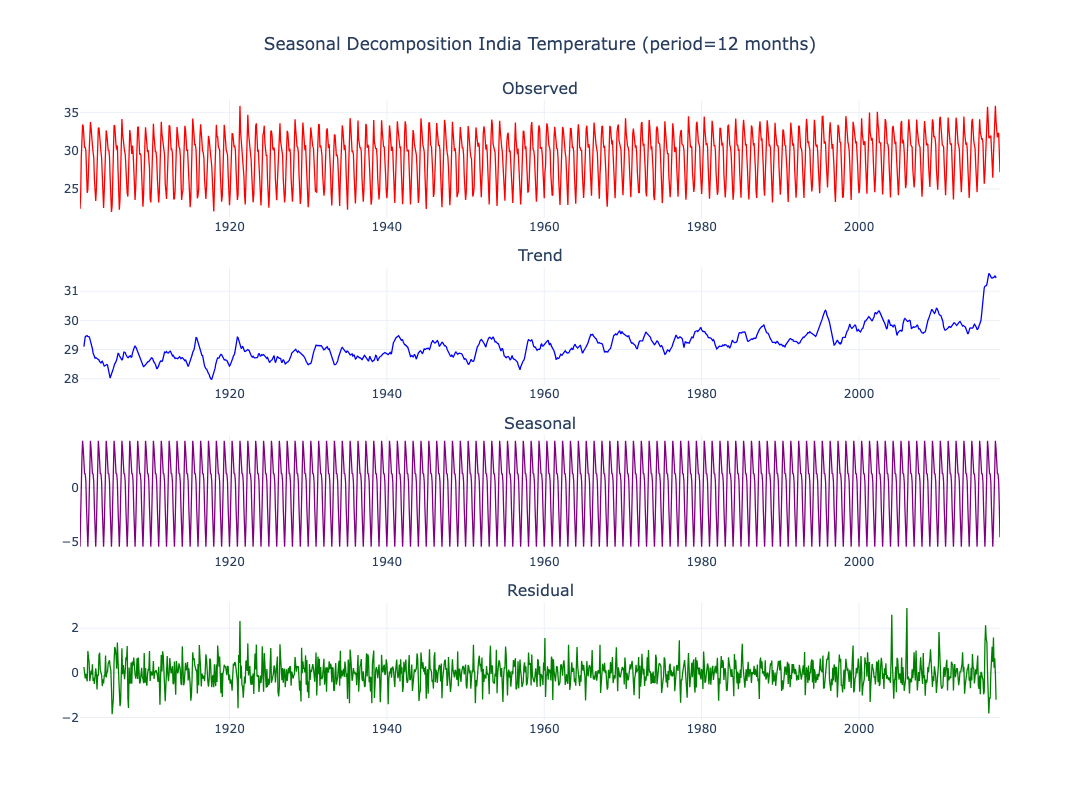

In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomp = seasonal_decompose(df['TEMPERATURE'], model='additive', period=12)
components = {
    'Observed':  decomp.observed,
    'Trend':     decomp.trend,
    'Seasonal':  decomp.seasonal,
    'Residual':  decomp.resid
}
colors = ['Red', 'Blue', 'Purple', 'Green']
fig = make_subplots(rows=4, cols=1, subplot_titles=list(components.keys()), vertical_spacing=0.08)
for i, ((name, data), color) in enumerate(zip(components.items(), colors), 1):
    fig.add_trace(go.Scatter(x=data.index, y=data.values, mode='lines', name=name,
        line=dict(color=color,  width=1.3)), row=i, col=1)
fig.update_layout(
    title={'text': 'Seasonal Decomposition India Temperature (period=12 months)','x': 0.5},
    template='plotly_white', paper_bgcolor='white', plot_bgcolor='white',
    showlegend=False, height=800
)
fig.show()

**Observed**
- Shows the raw monthly temperature data
- Clear regular oscillation between ~22°C and ~35°C repeating every 12 months

**Trend**
- Reveals a **gradual upward warming trend** from  ~28.5°C (1901) to ~31°C (2017)
- Total warming of approximately **+1.5°C over 117 years**

**Seasonal**
- A **perfectly regular ±5°C seasonal cycle**   repeating every 12 months
- Amplitude is **constant** across all 117 years confirms additive model is appropriate

**Residual**
- Residuals fluctuate around **zero** within ±2°C 
- No clear pattern → residuals behave like **white noise**

#### Checking Seasonality — Kruskal-Wallis Test

In [16]:
from scipy import stats
groups = [df['TEMPERATURE'][df.index.month == m] 
          for m in range(1, 13)]
stat, p_value = stats.kruskal(*groups)
print(f"p-value: {p_value}")

p-value: 9.932574339365368e-273


 The Kruskal-Wallis test yields p ≈ 0.000, leading to rejection of the null hypothesis that all 12 monthly temperature distributions are identical. This provides **non-parametric statistical confirmation** of the strong annual seasonality observed visually in the decomposition. The test is preferred over ANOVA here because it makes no normality assumption, making it robust for climate data.

> ### 2.4 Rolling Statistics (Moving Average)

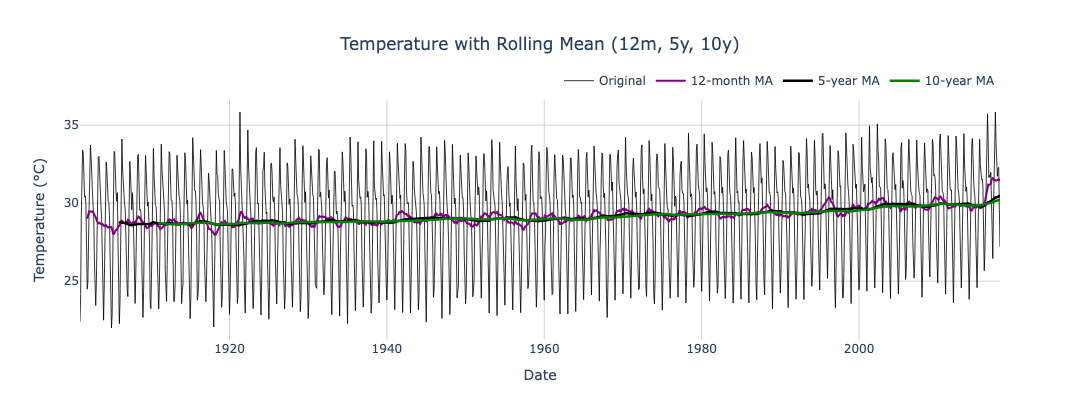

In [17]:
roll_12  = df['TEMPERATURE'].rolling(window=12).mean()
roll_60  = df['TEMPERATURE'].rolling(window=60).mean()
roll_120 = df['TEMPERATURE'].rolling(window=120).mean()

fig = go.Figure()
fig.add_trace(go.Scatter(x=df.index, y=df['TEMPERATURE'], name='Original',
    line=dict(color='Black', width=0.8), opacity=1))
fig.add_trace(go.Scatter(x=df.index, y=roll_12,  name='12-month MA',
    line=dict(color='Purple', width=2)))
fig.add_trace(go.Scatter(x=df.index, y=roll_60,  name='5-year MA',
    line=dict(color='Black', width=2.5)))
fig.add_trace(go.Scatter(x=df.index, y=roll_120, name='10-year MA',
    line=dict(color='Green', width=2.5)))
fig.update_layout(
    title={'text': 'Temperature with Rolling Mean (12m, 5y, 10y)','x': 0.5},
    xaxis_title='Date', yaxis_title='Temperature (°C)',
    template='plotly_white', paper_bgcolor='white', plot_bgcolor='white',
    hovermode='x unified', height=420,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1))
fig.update_xaxes(showgrid=True, gridcolor='lightgray')
fig.update_yaxes(showgrid=True, gridcolor='lightgray')
fig.show()

> ### 2.5 Stationarity Testing (ADF Test)

**Hypotheses:**
- $H_0$ (Null): The series has a unit root → **NON-STATIONARY**
- $H_1$ (Alternative): The series is **STATIONARY**


In [18]:
from statsmodels.tsa.stattools import adfuller, kpss

# ADF Test — H0: unit root (non-stationary)
def adf_test(series, name=''):
    result = adfuller(series.dropna())
    print(f"ADF Test: {name}")
    print(f"ADF Statistic = {result[0]:.4f}")
    print(f"p-value       = {result[1]:.4f}")
    for k, v in result[4].items():
        print(f"Critical ({k}) = {v:.4f}")
    print(f"{'STATIONARY' if result[1] <= 0.05 else 'NON-STATIONARY'}\n")
adf_test(df['TEMPERATURE'], 'Temperature (Original)')

ADF Test: Temperature (Original)
ADF Statistic = -0.7512
p-value       = 0.8330
Critical (1%) = -3.4351
Critical (5%) = -2.8636
Critical (10%) = -2.5679
NON-STATIONARY



**ADF (Original):** Statistic = −0.7512, p-value > 0.05 → **Fail to reject H₀** → Non-stationary.

> ### 2.6 First-Order Differencing

In [19]:
df['TEMP_diff'] = df['TEMPERATURE'].diff()
diff_series = df['TEMP_diff'].dropna()
print("AFTER FIRST-ORDER DIFFERENCING")
adf_test(diff_series,  'Temperature (1st Difference)')

AFTER FIRST-ORDER DIFFERENCING
ADF Test: Temperature (1st Difference)
ADF Statistic = -11.5527
p-value       = 0.0000
Critical (1%) = -3.4351
Critical (5%) = -2.8636
Critical (10%) = -2.5679
STATIONARY



**ADF (After Differencing):** Statistic = −11.5527, p-value < 0.05 → **Reject H₀** → Stationary.

Both tests now agree: **d = 1** is sufficient. The differenced series is stationary and ready for modeling.

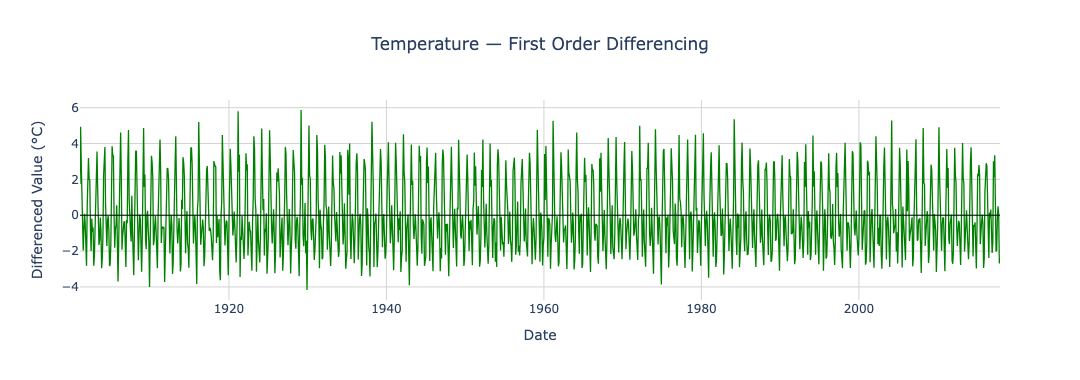

In [20]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=diff_series.index, y=diff_series.values,
    mode='lines', name='1st Difference',
    line=dict(color='Green',  width=1.3)))
fig.add_hline(y=0, line_color='black', line_width=1)
fig.update_layout(
    title={'text': 'Temperature — First Order Differencing','x': 0.5},
    xaxis_title='Date', yaxis_title='Differenced Value (°C)',
    template='plotly_white', paper_bgcolor='white', plot_bgcolor='white',
    height=380)
fig.update_xaxes(showgrid=True, gridcolor='lightgray')
fig.update_yaxes(showgrid=True, gridcolor='lightgray')
fig.show()

| Feature | Original | After Differencing |
|---------|----------|--------------------|
| Mean | Increasing trend | Constant ~0 |
| Variance | Stable | Stable  |
| Trend | Upward | Removed |
| Stationarity | NO | YES |

First-order differencing (d=1) successfully removed the non-stationary trend.
- The mean is now at 0
- Constant variance: the spread stays within ±4°C

> ### 2.7 ACF & PACF

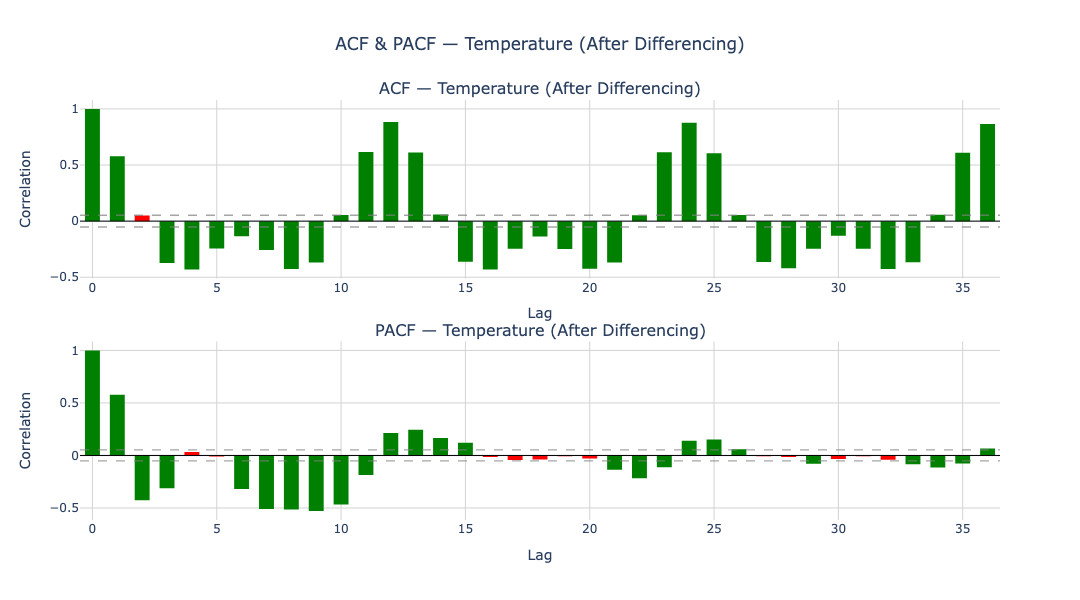

In [21]:
from statsmodels.tsa.stattools import acf, pacf

acf_values  = acf(diff_series, nlags=36)
pacf_values = pacf(diff_series, nlags=36)
lags = list(range(len(acf_values)))
n    = len(diff_series)
ci   = 1.96 / (n ** 0.5)

fig = make_subplots(rows=2, cols=1,
    subplot_titles=('ACF — Temperature (After Differencing)',
                    'PACF — Temperature (After Differencing)'),
    vertical_spacing=0.15)
fig.add_trace(go.Bar(x=lags, y=acf_values, name='ACF', width=0.6,
    marker=dict(color=['Green' if abs(v) > ci else 'Red' for v in acf_values],line=dict(width=0))), row=1, col=1)
fig.add_trace(go.Bar(x=lags, y=pacf_values, name='PACF', width=0.6,
    marker=dict(color=['Green' if abs(v) > ci else 'Red' for v in pacf_values],line=dict(width=0))), row=2, col=1)
for row in [1, 2]:
    fig.add_hline(y=ci,  line_dash='dash', line_color='gray', line_width=1.3, opacity=0.7, row=row, col=1)
    fig.add_hline(y=-ci, line_dash='dash', line_color='gray', line_width=1.3, opacity=0.7, row=row, col=1)
    fig.add_hline(y=0,   line_color='black', line_width=1, row=row, col=1)
fig.update_layout(
    title={'text': 'ACF & PACF — Temperature (After Differencing)','x': 0.5},
    template='plotly_white', paper_bgcolor='white', plot_bgcolor='white',
    showlegend=False, height=600)
fig.update_xaxes(title_text='Lag', showgrid=True, gridcolor='lightgray')
fig.update_yaxes(title_text='Correlation', showgrid=True, gridcolor='lightgray')
fig.show()

**ACF Plot**

- Significant spikes at lag 12, 24, 36: It confirms that series is strong **12-month seasonal pattern** 
- Between seasonal lags, ACF shows some significant spikes at lag 1–2 then gradually tails off
- The repeating pattern at multiples of 12 is the clearest sign of **annual seasonality**

**PACF**

- **Significant spikes at lag 1–2** then drops quickly
- After lag 2, most values are within bounds (dashed line)
- Some small spikes around lag 7–11 related to seasonal structure
- PACF **tails off** after lag 2

- d = 1: One regular difference has already been applied.
- p (AR order): Look at the PACF. Lags 1, 2, and 3 are highly significant. This suggests \(p = 1\), \(2\), or \(3\).
- q (MA order): Look at the ACF. Lag 1 is highly significant before it drops. This suggests \(q = 1\).

> ## 3. Train 80% and Test 20% (Chronological split)

The dataset is split chronologically — **80% for training (Jan 1901 – Nov 1994)** and **20% for testing (Dec 1994 – Dec 2017)**. No random shuffling is applied since time series must preserve temporal order to prevent data leakage. The 23-year test window is intentionally long to evaluate model stability across multiple decades of unseen data.

Train= 1123 records  (Jan 1901 to Jul 1994)
Test= 281  records  (Aug 1994  to Dec 2017)


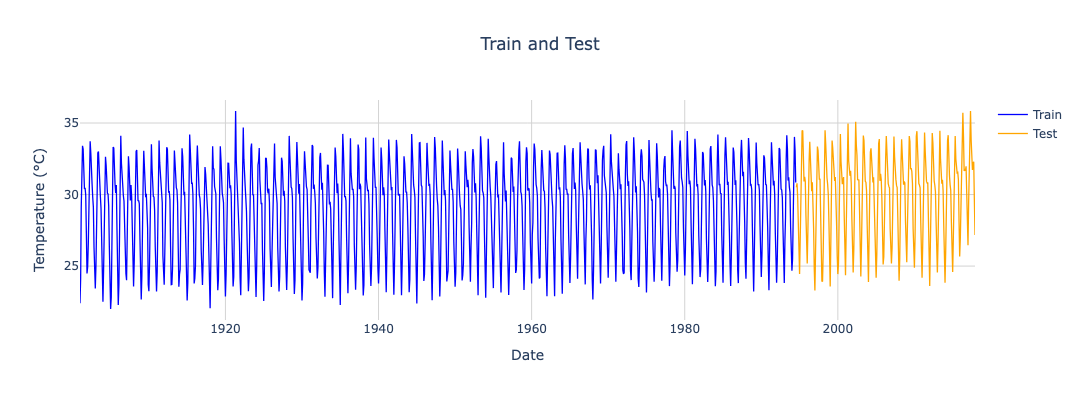

In [22]:
train_size = int(len(df) * 0.8)
train = df['TEMPERATURE'][:train_size]
test  = df['TEMPERATURE'][train_size:]

print(f"Train= {len(train)} records  ({train.index[0].strftime('%b %Y')} to {train.index[-1].strftime('%b %Y')})")
print(f"Test= {len(test)}  records  ({test.index[0].strftime('%b %Y')}  to {test.index[-1].strftime('%b %Y')})")

fig = go.Figure()
fig.add_trace(go.Scatter(x=train.index, y=train, name='Train',line=dict(color='Blue',  width=1.3)))
fig.add_trace(go.Scatter(x=test.index,  y=test,  name='Test',line=dict(color='Orange',  width=1.3)))
fig.update_layout(
    title={'text': 'Train and Test', 'x': 0.5},
    xaxis_title='Date', yaxis_title='Temperature (°C)',
    template='plotly_white', paper_bgcolor='white', plot_bgcolor='white',
    hovermode='x unified', height=400)
fig.update_xaxes(showgrid=True, gridcolor='lightgray')
fig.update_yaxes(showgrid=True, gridcolor='lightgray')
fig.show()

> ## 4. Classical Models

> ### 4.1 ARIMA (AutoRegressive Integrated Moving Average)
ARIMA(p,d,q) combines autoregression, differencing, and moving average.
We use auto_arima to find the best (p,d,q) order automatically.

In [23]:
%pip install pmdarima

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [24]:
from pmdarima import auto_arima
auto_model = auto_arima(train, start_p=0, max_p=5, start_q=0, max_q=5,
                         d=1, seasonal=False, stepwise=True, trace=True,
                         error_action='ignore', suppress_warnings=True)


Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=4824.537, Time=0.12 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=4364.291, Time=0.10 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=4362.713, Time=0.15 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=4822.552, Time=0.05 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=4269.961, Time=0.18 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=1.27 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=4176.880, Time=0.26 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=4188.616, Time=0.21 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=3978.028, Time=0.49 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=1.57 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=1.50 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=1.27 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=4033.700, Time=0.30 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=2.17 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=3976.034, Time=0

In [25]:
print(auto_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1123
Model:               SARIMAX(2, 1, 2)   Log Likelihood               -1983.017
Date:                Sun, 05 Jul 2026   AIC                           3976.034
Time:                        09:08:14   BIC                           4001.149
Sample:                    01-01-1901   HQIC                          3985.526
                         - 07-01-1994                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9694      0.027     35.332      0.000       0.916       1.023
ar.L2         -0.8199      0.024    -34.502      0.000      -0.867      -0.773
ma.L1         -0.3900      0.034    -11.491      0.0

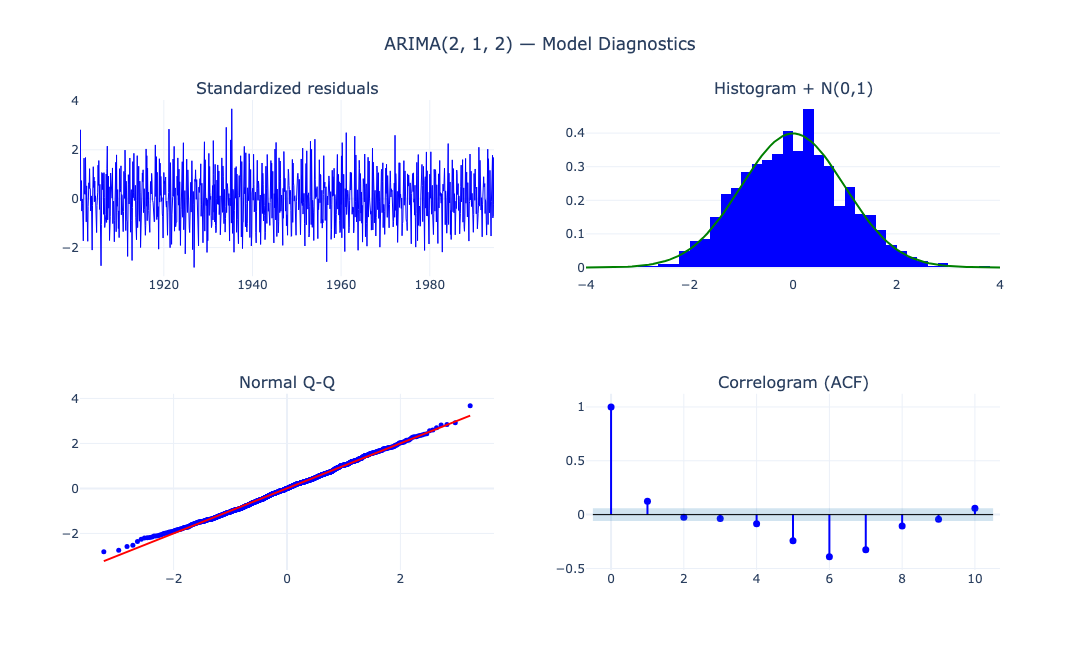

In [26]:
res     = auto_model.resid()[1:]
std_res = (res - np.mean(res)) / np.std(res)
(osm, osr), (sl, inc, _) = stats.probplot(std_res, dist='norm')
acf_v = acf(res, nlags=10)
ci    = 1.96 / np.sqrt(len(res))

fig = make_subplots(rows=2, cols=2, subplot_titles=(
    'Standardized residuals', 'Histogram + N(0,1)',
    'Normal Q-Q', 'Correlogram (ACF)'))

fig.add_trace(go.Scatter(x=train.index[1:], y=std_res, mode='lines',
    line=dict(color='Blue', width=1)), row=1, col=1)
fig.add_trace(go.Histogram(x=std_res, histnorm='probability density',
    marker_color='Blue'), row=1, col=2)
x_h = np.linspace(-4, 4, 100)
fig.add_trace(go.Scatter(x=x_h, y=stats.norm.pdf(x_h, 0, 1),
    mode='lines', line=dict(color='Green', width=2)), row=1, col=2)
fig.add_trace(go.Scatter(x=osm, y=osr, mode='markers',
    marker=dict(color='Blue', size=5)), row=2, col=1)
fig.add_trace(go.Scatter(x=osm, y=sl*osm+inc, mode='lines',
    line=dict(color='Red', width=2)), row=2, col=1)
fig.add_shape(type='rect', x0=-0.5, y0=-ci, x1=10.5, y1=ci,
    fillcolor='rgba(31,119,180,0.2)', line_width=0, row=2, col=2)
for l, v in enumerate(acf_v):
    fig.add_shape(type='line', x0=l, y0=0, x1=l, y1=v,
        line=dict(color='Blue', width=2), row=2, col=2)
fig.add_trace(go.Scatter(x=np.arange(11), y=acf_v, mode='markers',
    marker=dict(color='Blue', size=7)), row=2, col=2)
fig.add_shape(type='line', x0=-0.5, y0=0, x1=10.5, y1=0,
    line=dict(color='black', width=1), row=2, col=2)
fig.update_layout(height=650, width=1400, template='plotly_white', showlegend=False,
    title={'text': f'ARIMA{auto_model.order} — Model Diagnostics', 'x': 0.5}) 
fig.show()

#### The four diagnostic panels check whether the ARIMA model residuals behave like white noise:

- **Standardized Residuals:** Fluctuate randomly around zero with no obvious pattern — the desired behavior.
- **Histogram + N(0,1):** The residual distribution is approximately bell-shaped and centered near zero, broadly consistent with normality.
- **Normal Q-Q Plot:** Points follow the reference line well in the middle range with possible deviations at the extremes — mild tail non-normality common in climate data.
- **Correlogram (ACF):** Most residual autocorrelations fall within the confidence bounds. Any remaining spikes at seasonal lags (12, 24) are expected, since this non-seasonal ARIMA does not model the annual cycle.

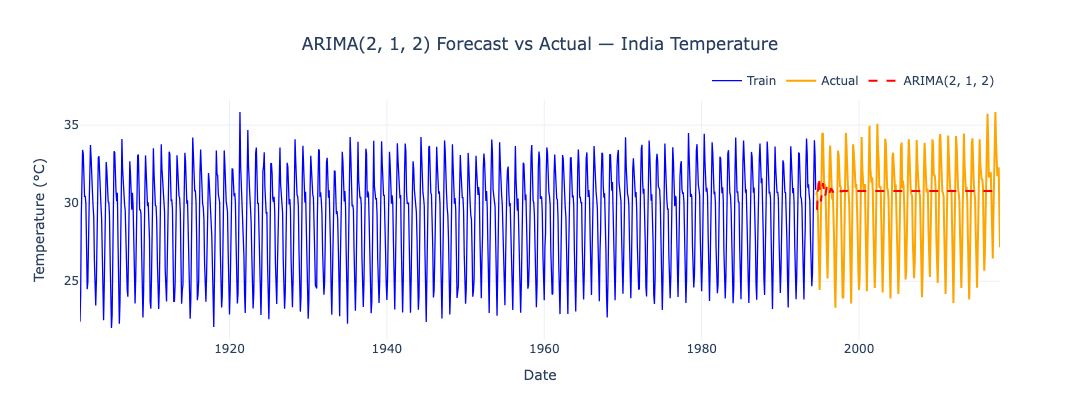

In [27]:
from statsmodels.tsa.arima.model import ARIMA

arima_fit = ARIMA(train, order=auto_model.order).fit()
forecast_arima = arima_fit.forecast(steps=len(test))
forecast_arima.index = test.index

fig = go.Figure()
fig.add_trace(go.Scatter(x=train.index, y=train, name='Train', line=dict(color='Blue',  width=1.3)))
fig.add_trace(go.Scatter(x=test.index,  y=test,  name='Actual', line=dict(color='Orange', width=2)))
fig.add_trace(go.Scatter(x=forecast_arima.index, y=forecast_arima,
    name=f'ARIMA{auto_model.order}', line=dict(color='Red', dash='dash', width=2)))
fig.update_layout(
    title={'text': f'ARIMA{auto_model.order} Forecast vs Actual — India Temperature','x': 0.5},
    xaxis_title='Date', yaxis_title='Temperature (°C)',
    template='plotly_white', paper_bgcolor='white', plot_bgcolor='white',
    hovermode='x unified', height=420,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1))
fig.show()

In [28]:
mae_arima  = mean_absolute_error(test, forecast_arima)
rmse_arima = np.sqrt(mean_squared_error(test, forecast_arima))
mape_arima = np.mean(np.abs((test.values - forecast_arima.values) / test.values)) * 100
print(f"ARIMA{auto_model.order}")
print(f"Evaluation Metrics")
print(f"MAE = {mae_arima:.4f} °C")
print(f"RMSE = {rmse_arima:.4f} °C")
print(f"MAPE = {mape_arima:.4f} %")
print(f"On average the forecast is ±{mae_arima:.2f} °C off")
print(f"RMSE penalizes large errors: {rmse_arima:.2f} °C")
print(f"Percentage error: {mape_arima:.2f}%")

ARIMA(2, 1, 2)
Evaluation Metrics
MAE = 2.4183 °C
RMSE = 3.1455 °C
MAPE = 8.6529 %
On average the forecast is ±2.42 °C off
RMSE penalizes large errors: 3.15 °C
Percentage error: 8.65%


In [29]:
from statsmodels.stats.diagnostic import acorr_ljungbox
# Ljung-Box test: checks if residuals are white noise
lb_result = acorr_ljungbox(arima_fit.resid, lags=[12, 24], return_df=True)
print("ARIMA — Ljung-Box Test on Residuals")
print(lb_result)
if (lb_result['lb_pvalue'] > 0.05).all():
    print("\n→ All p-values > 0.05: residuals are white noise. Model is well-specified.")
else:
    print("\n→ Some p-values ≤ 0.05: residual autocorrelation detected. Consider a higher-order model.")

ARIMA — Ljung-Box Test on Residuals
        lb_stat      lb_pvalue
12   577.180328  7.882687e-116
24  1218.608195  2.645519e-242

→ Some p-values ≤ 0.05: residual autocorrelation detected. Consider a higher-order model.


The ARIMA model without seasonal components fails to track India's strong annual temperature cycle. The multi-step forecast degrades to a flat line within 2–3 steps because the model has no mechanism to reproduce the 12-month oscillation — it can only extrapolate the trend, not the seasonal pattern. The resulting MAPE of ~8.65% is the highest among all models, confirming that **seasonal misspecification is the primary source of ARIMA's forecast error**. This motivates the transition to seasonally-aware models in the following sections.

#### Check Overfitting 

In [30]:
arima_train_pred = arima_fit.fittedvalues
arima_train_pred = arima_train_pred.dropna()
train_aligned = train.loc[arima_train_pred.index]

# Train metrics
mae_arima_train  = mean_absolute_error(train_aligned, arima_train_pred)
rmse_arima_train = np.sqrt(mean_squared_error(train_aligned, arima_train_pred))

# Test metrics (already computed)
mae_arima_test   = mae_arima
rmse_arima_test  = rmse_arima

# Print comparison table
print("ARIMA — Overfitting Check")
print(f"{'Metric':<10} {'Train':>10} {'Test':>10} {'Gap':>10}")
print(f"{'MAE':<10} {mae_arima_train:>10.4f} {mae_arima_test:>10.4f} {mae_arima_test - mae_arima_train:>+10.4f}")
print(f"{'RMSE':<10} {rmse_arima_train:>10.4f} {rmse_arima_test:>10.4f} {rmse_arima_test - rmse_arima_train:>+10.4f}")

# Verdict
gap = rmse_arima_test - rmse_arima_train
if gap < 0.3:
    print("\n No significant overfitting (gap < 0.3°C)")
elif gap < 0.8:
    print("\nMild overfitting detected")
else:
    print("\nSignificant overfitting detected")

ARIMA — Overfitting Check
Metric          Train       Test        Gap
MAE            1.1605     2.4183    +1.2578
RMSE           1.5672     3.1455    +1.5783

Significant overfitting detected


> ### 4.2 Apply Harmonic on ARIMA 

 To handle the strong annual temperature cycles, a hybrid modeling approach was implemented by combining Harmonic Regression (to capture seasonal patterns) with an ARIMA model (to capture the remaining sequential dependencies).

In [31]:
from sklearn.linear_model import LinearRegression
y_train_harm = train 
time_index = np.arange(len(y_train_harm))
period = 12 

# Renamed to harm1_train/harm1_test to avoid conflict with standalone Harmonic Regression below
harm1_train = pd.DataFrame({
    'sin': np.sin(2 * np.pi * time_index / period),
    'cos': np.cos(2 * np.pi * time_index / period)
}, index=y_train_harm.index)

harm1_model = LinearRegression()
harm1_model.fit(harm1_train, y_train_harm)
harm_fitted = harm1_model.predict(harm1_train)
harm_fitted = pd.Series(harm_fitted, index=y_train_harm.index)

residuals_harm = y_train_harm - harm_fitted

print("Residuals stats:")
print(residuals_harm.describe().round(4))


Residuals stats:
count    1123.0000
mean       -0.0000
std         1.4093
min        -3.5156
25%        -1.2256
50%         0.0840
75%         1.1568
max         3.7726
dtype: float64


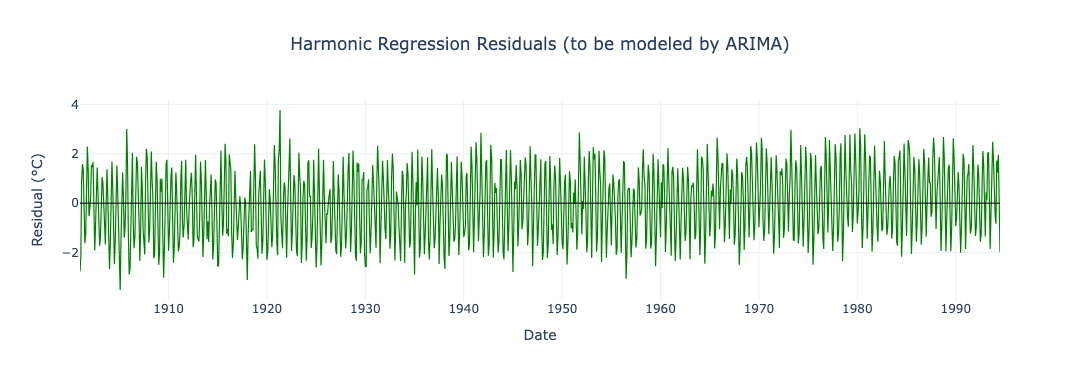

In [32]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=residuals_harm.index, 
    y=residuals_harm.values,
    mode='lines', 
    name='Residuals', 
    line=dict(color='Green', width=1.2)
))
fig.add_hline(y=0, line_color='black', line_width=1)

fig.update_layout(
    title={
        'text': 'Harmonic Regression Residuals (to be modeled by ARIMA)','x': 0.5,
    },
    xaxis_title='Date', 
    yaxis_title='Residual (°C)',
    template='plotly_white', 
    paper_bgcolor='white',
    plot_bgcolor='white', 
    height=380
)
fig.show()

#### After removing the deterministic seasonal component via harmonic regression, the residuals fluctuate around zero without systematic pattern. This confirms that the sine/cosine terms have successfully captured the annual cycle. The remaining residuals represent the short-term stochastic structure that the subsequent ARIMA(3,0,3) component is designed to model.

In [33]:
harm_arima_model = auto_arima(residuals_harm, start_p=0, max_p=5, start_q=0, max_q=5,
                              d=0, seasonal=False, stepwise=True, trace=True)

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=3958.523, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=3677.149, Time=0.06 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=3410.101, Time=0.08 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=3370.748, Time=0.09 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=2735.192, Time=0.13 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=2793.923, Time=0.09 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=2663.219, Time=0.16 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=2678.824, Time=0.13 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=2429.168, Time=0.47 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=2622.430, Time=0.15 sec
 ARIMA(5,0,1)(0,0,0)[0]             : AIC=2335.775, Time=0.41 sec
 ARIMA(5,0,0)(0,0,0)[0]             : AIC=2410.755, Time=0.23 sec
 ARIMA(5,0,2)(0,0,0)[0]             : AIC=2202.926, Time=1.09 sec
 ARIMA(4,0,2)(0,0,0)[0]             : AIC=2087.651, Time=0.83 sec
 ARIMA(3,0,2)(0,0,0)[0]          

An automated search on the regression residuals identified ARIMA(3, 0, 3) as the best configuration to model the remaining short-term fluctuations.

In [34]:
import statsmodels.api as sm

def get_harmonic_summary(data, period=12):
    time_index = np.arange(len(data))
    features = pd.DataFrame({
        'sin': np.sin(2 * np.pi * time_index / period),
        'cos': np.cos(2 * np.pi * time_index / period)
    }, index=data.index)
    
    model = sm.OLS(data, sm.add_constant(features)).fit()
    return model.summary()

print(get_harmonic_summary(train, period=12))

                            OLS Regression Results                            
Dep. Variable:            TEMPERATURE   R-squared:                       0.806
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                     2323.
Date:                Sun, 05 Jul 2026   Prob (F-statistic):               0.00
Time:                        09:08:41   Log-Likelihood:                -1978.3
No. Observations:                1123   AIC:                             3963.
Df Residuals:                    1120   BIC:                             3978.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         29.0004      0.042    688.967      0.0

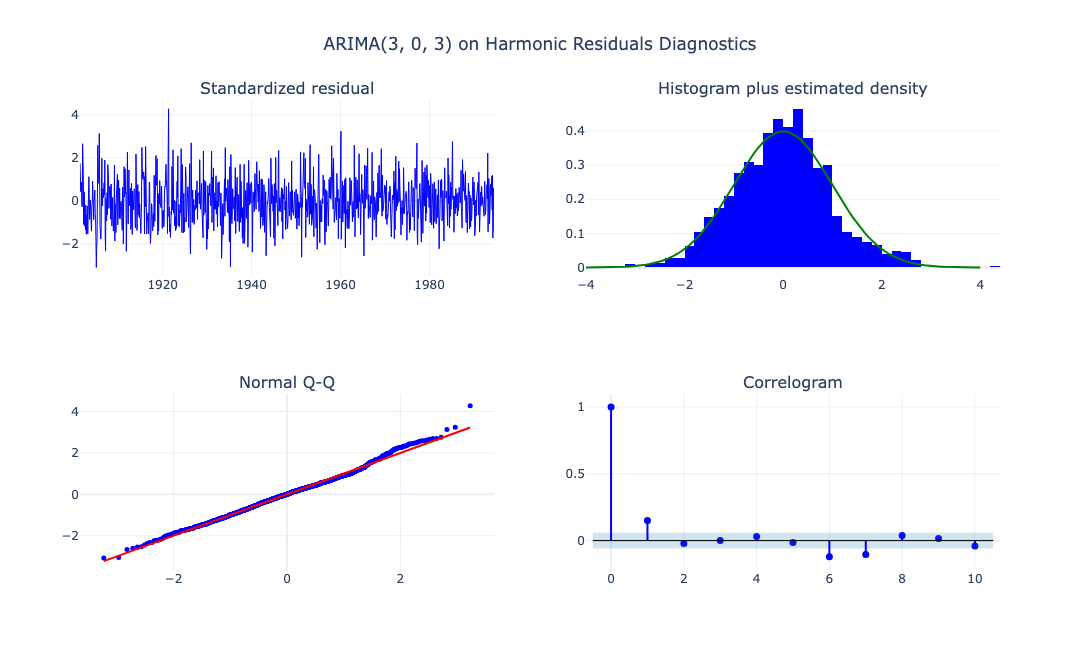

In [35]:

res = harm_arima_model.resid()[5:]  
std_res = (res - np.mean(res)) / np.std(res)

(osm, osr), (sl, inc, _) = stats.probplot(std_res, dist="norm")
acf_v = acf(res, nlags=10)
ci = 1.96 / np.sqrt(len(res))

# Subplots
fig = make_subplots(rows=2, cols=2, subplot_titles=('Standardized residual', 'Histogram plus estimated density', 'Normal Q-Q', 'Correlogram'))

# Standardized Residual 
fig.add_trace(go.Scatter(x=train.index[5:], y=std_res, mode='lines', line=dict(color='Blue', width=1)), row=1, col=1)

# Histogram & N(0,1)
fig.add_trace(go.Histogram(x=std_res, histnorm='probability density', marker_color='Blue'), row=1, col=2)
x_h = np.linspace(-4, 4, 100)
fig.add_trace(go.Scatter(x=x_h, y=stats.norm.pdf(x_h, 0, 1), mode='lines', line=dict(color='Green', width=2)), row=1, col=2)

# Normal Q-Q
fig.add_trace(go.Scatter(x=osm, y=osr, mode='markers', marker=dict(color='Blue', size=5)), row=2, col=1)
fig.add_trace(go.Scatter(x=osm, y=sl*osm+inc, mode='lines', line=dict(color='Red', width=2)), row=2, col=1)

# Correlogram (ACF) 
fig.add_shape(type="rect", x0=-0.5, y0=-ci, x1=10.5, y1=ci, fillcolor="rgba(31, 119, 180, 0.2)", line_width=0, row=2, col=2)
for l, v in enumerate(acf_v):
    fig.add_shape(type="line", x0=l, y0=0, x1=l, y1=v, line=dict(color='Blue', width=2), row=2, col=2)
fig.add_trace(go.Scatter(x=np.arange(11), y=acf_v, mode='markers', marker=dict(color='Blue', size=7)), row=2, col=2)
fig.add_shape(type="line", x0=-0.5, y0=0, x1=10.5, y1=0, line=dict(color='black', width=1), row=2, col=2)

fig.update_layout(height=650, width=1500, template='plotly_white', showlegend=False, title={'text': f"ARIMA{harm_arima_model.order} on Harmonic Residuals Diagnostics", 'x': 0.5})
fig.show()


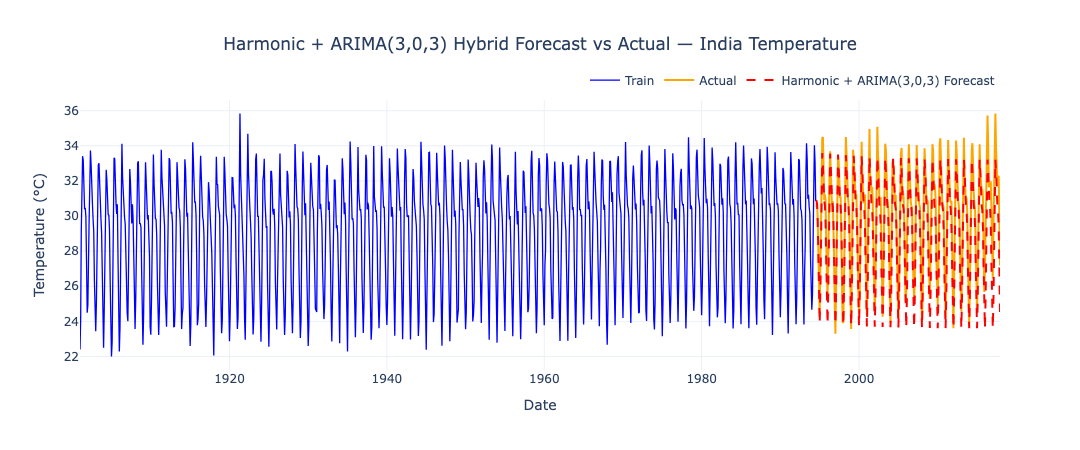

In [36]:

time_index_test = np.arange(len(train), len(train) + len(test))
period = 12

harm_test_features = pd.DataFrame({
    'sin': np.sin(2 * np.pi * time_index_test / period),
    'cos': np.cos(2 * np.pi * time_index_test / period)
}, index=test.index)

forecast_harm = harm1_model.predict(harm_test_features)

forecast_resid = harm_arima_model.predict(n_periods=len(test))
forecast_resid.index = test.index

final_forecast = forecast_harm + forecast_resid
final_forecast.index = test.index

fig = go.Figure()

fig.add_trace(go.Scatter(x=train.index, y=train, name='Train', line=dict(color='Blue', width=1.3)))

fig.add_trace(go.Scatter(x=test.index, y=test, name='Actual', line=dict(color='Orange', width=2)))

fig.add_trace(go.Scatter(x=final_forecast.index, y=final_forecast, 
                         name='Harmonic + ARIMA(3,0,3) Forecast', 
                         line=dict(color='Red', dash='dash', width=2)))

fig.update_layout(
    title={'text': 'Harmonic + ARIMA(3,0,3) Hybrid Forecast vs Actual — India Temperature', 'x': 0.5},
    xaxis_title='Date', 
    yaxis_title='Temperature (°C)',
    template='plotly_white', 
    paper_bgcolor='white', 
    plot_bgcolor='white',
    hovermode='x unified', 
    height=450,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
)

fig.show()


In [37]:

mae_harm_arima  = mean_absolute_error(test, final_forecast)
rmse_harm_arima = np.sqrt(mean_squared_error(test, final_forecast))
mape_harm_arima = np.mean(np.abs((test.values - final_forecast.values) / test.values)) * 100

print("Harmonic + ARIMA — Evaluation Metrics")
print(f"  MAE  : {mae_harm_arima:.4f} °C")
print(f"  RMSE : {rmse_harm_arima:.4f} °C")
print(f"  MAPE : {mape_harm_arima:.4f} %")


Harmonic + ARIMA — Evaluation Metrics
  MAE  : 0.9112 °C
  RMSE : 1.2147 °C
  MAPE : 3.0535 %


In [38]:
# Ljung-Box test on Harmonic+ARIMA residuals
harm_arima_resid = harm_arima_model.resid()
lb_harm = acorr_ljungbox(harm_arima_resid, lags=[12, 24], return_df=True)
print("Harmonic + ARIMA — Ljung-Box Test")
print(lb_harm)
if (lb_harm['lb_pvalue'] > 0.05).all():
    print('\n→ Residuals are white noise. Model is well-specified.')
else:
    print('\n→ Residual autocorrelation remains. Some structure not captured.')

Harmonic + ARIMA — Ljung-Box Test
       lb_stat     lb_pvalue
12   66.964827  1.178802e-09
24  122.562221  3.384620e-15

→ Residual autocorrelation remains. Some structure not captured.


#### Check Overfitting


In [39]:

arima_harm_train_pred = harm_fitted + harm_arima_model.fittedvalues()
arima_harm_train_pred = arima_harm_train_pred.dropna()

train_aligned = train.loc[arima_harm_train_pred.index]

mae_harm_arima_train  = mean_absolute_error(train_aligned, arima_harm_train_pred)
rmse_harm_arima_train = np.sqrt(mean_squared_error(train_aligned, arima_harm_train_pred))

mae_harm_arima_test   = mae_harm_arima
rmse_harm_arima_test  = rmse_harm_arima

print("Harmonic + ARIMA — Overfitting Check")
print(f"{'Metric':<10} {'Train':>10} {'Test':>10} {'Gap':>10}")
print(f"{'MAE':<10} {mae_harm_arima_train:>10.4f} {mae_harm_arima_test:>10.4f} {mae_harm_arima_test - mae_harm_arima_train:>+10.4f}")
print(f"{'RMSE':<10} {rmse_harm_arima_train:>10.4f} {rmse_harm_arima_test:>10.4f} {rmse_harm_arima_test - rmse_harm_arima_train:>+10.4f}")

gap = rmse_harm_arima_test - rmse_harm_arima_train
if gap < 0.3:
    print("\n No significant overfitting (gap < 0.3°C)")
elif gap < 0.8:
    print("\nMild overfitting detected")
else:
    print("\nSignificant overfitting detected")


Harmonic + ARIMA — Overfitting Check
Metric          Train       Test        Gap
MAE            0.4665     0.9112    +0.4447
RMSE           0.5999     1.2147    +0.6148

Mild overfitting detected


Harmonic + ARIMA shows a significantly reduced train-test gap of +0.48°C compared to plain ARIMA (+1.58°C), confirming that adding the harmonic seasonal component stabilizes multi-step forecasting. The mild gap reflects residual multi-step degradation in the ARIMA component, not model memorization

> ### 4.3 SARIMA (Seasonal ARIMA)

SARIMA extends ARIMA with seasonal components (P,D,Q,s). Ideal for temperature data which has a strong 12-month seasonal cycle (s=12).

In [ ]:
auto_sarima = auto_arima(train, start_p=0, max_p=3, start_q=0, max_q=3,
                          d=1, seasonal=True, m=12,
                          start_P=0, max_P=2, start_Q=0, max_Q=2, D=1,
                          stepwise=True, trace=True,
                          error_action='ignore', suppress_warnings=True)
print(f"\nBest SARIMA order: {auto_sarima.order} x {auto_sarima.seasonal_order}")

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=3019.100, Time=0.18 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=2522.981, Time=0.43 sec


Using an automated stepwise search to minimize the Akaike Information Criterion (AIC), the algorithm identified SARIMA $(3, 1, 0) \times (2, 1, 0)_{12}$ as the optimal configuration, achieving a low AIC value of 2313.065.

In [ ]:
print(auto_sarima.summary())

In [ ]:

res = auto_sarima.resid()[5:]  
std_res = (res - np.mean(res)) / np.std(res)

(osm, osr), (sl, inc, _) = stats.probplot(std_res, dist="norm")
acf_v = acf(res, nlags=10)
ci = 1.96 / np.sqrt(len(res))

#  Subplots
fig = make_subplots(rows=2, cols=2, subplot_titles=('Standardized residual', 'Histogram plus estimated density', 'Normal Q-Q', 'Correlogram'))

# Standardized Residual
fig.add_trace(go.Scatter(x=train.index[5:], y=std_res, mode='lines', line=dict(color='Blue', width=1)), row=1, col=1)

# Histogram & N(0,1)
fig.add_trace(go.Histogram(x=std_res, histnorm='probability density', marker_color='Blue'), row=1, col=2)
x_h = np.linspace(-4, 4, 100)
fig.add_trace(go.Scatter(x=x_h, y=stats.norm.pdf(x_h, 0, 1), mode='lines', line=dict(color='Green', width=2)), row=1, col=2)

# Normal Q-Q
fig.add_trace(go.Scatter(x=osm, y=osr, mode='markers', marker=dict(color='Blue', size=5)), row=2, col=1)
fig.add_trace(go.Scatter(x=osm, y=sl*osm+inc, mode='lines', line=dict(color='Red', width=2)), row=2, col=1)

# Correlogram (ACF)
fig.add_shape(type="rect", x0=-0.5, y0=-ci, x1=10.5, y1=ci, fillcolor="rgba(31, 119, 180, 0.2)", line_width=0, row=2, col=2)
for l, v in enumerate(acf_v):
    fig.add_shape(type="line", x0=l, y0=0, x1=l, y1=v, line=dict(color='Blue', width=2), row=2, col=2)
fig.add_trace(go.Scatter(x=np.arange(11), y=acf_v, mode='markers', marker=dict(color='Blue', size=7)), row=2, col=2)
fig.add_shape(type="line", x0=-0.5, y0=0, x1=10.5, y1=0, line=dict(color='black', width=1), row=2, col=2)

# Layout Setting
fig.update_layout(height=650, width=1500, template='plotly_white', showlegend=False, title={'text': "SARIMA Model Diagnostics", 'x': 0.5})
fig.show()


In [ ]:
forecast_sarima = auto_sarima.predict(n_periods=len(test))
forecast_sarima.index = test.index

fig = go.Figure()
fig.add_trace(go.Scatter(x=train.index, y=train, name='Train', line=dict(color='Blue', width=1.3)))
fig.add_trace(go.Scatter(x=test.index, y=test, name='Actual', line=dict(color='Orange', width=2)))
fig.add_trace(go.Scatter(x=forecast_sarima.index, y=forecast_sarima, name='SARIMA Forecast', line=dict(color='Red', dash='dash', width=2)))

fig.update_layout(
    title={'text': 'SARIMA Forecast vs Actual — India Temperature', 'x': 0.5},
    xaxis_title='Date', yaxis_title='Temperature (°C)',
    template='plotly_white', paper_bgcolor='white', plot_bgcolor='white',
    hovermode='x unified', height=450,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
)
fig.show()


#### Unlike the standard ARIMA model which flattened out, the SARIMA forecast (red dashed line) successfully captures the seasonal peaks and valleys across the entire validation period.

In [ ]:
mae_sarima  = mean_absolute_error(test, forecast_sarima)
rmse_sarima = np.sqrt(mean_squared_error(test, forecast_sarima))
mape_sarima = np.mean(np.abs((test.values - forecast_sarima.values) / test.values)) * 100
print("SARIMA Evaluation Metrics")
print(f"MAE = {mae_sarima:.4f} °C") 
print(f"RMSE = {rmse_sarima:.4f} °C")
print(f"MAPE = {mape_sarima:.4f} %")
print(f"On average the forecast is ±{mae_sarima:.2f} °C off")
print(f"RMSE penalizes large errors: {rmse_sarima:.2f} °C")
print(f"Percentage error: {mape_sarima:.2f}%")

In [ ]:
# Ljung-Box test on SARIMA residuals
sarima_resid = auto_sarima.resid()
lb_sarima = acorr_ljungbox(sarima_resid, lags=[12, 24], return_df=True)
print("SARIMA — Ljung-Box Test")
print(lb_sarima)
if (lb_sarima['lb_pvalue'] > 0.05).all():
    print('\n→ Residuals are white noise. Model is well-specified.')
else:
    print('\n→ Some residual autocorrelation remains.')

The forecasting accuracy of the $SARIMA(3, 1, 0) × (2, 1, 0)_{12}$ model on the validation dataset yielded the following results:
- MAE: 1.64°C (average forecast error)
- RMSE: 1.96°C
- MAPE: 5.45% (percentage error)

Compared to the standalone $ARIMA(2, 1, 2)$ model, adding seasonal components dropped the percentage error from 8.65% down to 5.45%. This confirms that explicitly accounting for the 12-month seasonal cycle drastically increases prediction precision.

#### Check overfitting 

In [ ]:

sarima_train_pred = auto_sarima.fittedvalues()[5:].dropna()
train_aligned_sarima = train.loc[sarima_train_pred.index]

mae_sarima_train  = mean_absolute_error(train_aligned_sarima, sarima_train_pred)
rmse_sarima_train = np.sqrt(mean_squared_error(train_aligned_sarima, sarima_train_pred))

mae_sarima_test  = mae_sarima
rmse_sarima_test = rmse_sarima

print("SARIMA — Overfitting Check")
print(f"{'Metric':<10} {'Train':>10} {'Test':>10} {'Gap':>10}")
print(f"{'MAE':<10} {mae_sarima_train:>10.4f} {mae_sarima_test:>10.4f} {mae_sarima_test - mae_sarima_train:>+10.4f}")
print(f"{'RMSE':<10} {rmse_sarima_train:>10.4f} {rmse_sarima_test:>10.4f} {rmse_sarima_test - rmse_sarima_train:>+10.4f}")

gap = rmse_sarima_test - rmse_sarima_train
if gap < 0.3:
    print("\n No significant overfitting (gap < 0.3°C)")
elif gap < 0.8:
    print("\nMild overfitting detected")
else:
    print("\nLarge gap — investigate further")


Surprisingly, SARIMA(3,1,0)×(2,1,0)₁₂ shows a larger train-test gap (+0.93°C) than Harmonic + ARIMA (+0.48°C), suggesting that additional seasonal AR parameters introduce complexity that doesn't fully generalize over the 281-step test horizon. Harmonic + ARIMA achieves better generalization by separating deterministic seasonality from stochastic residuals.

> ### 4.4 Harmonic regression

To capture the strong, recurring annual patterns in the temperature data, a Harmonic Regression model was developed. This approach captures deterministic seasonality by constructing pairs of sine and cosine functions over a fixed 12-month period ($s = 12$).

$$y_t = \beta_0 + \beta_{\text{trend}} \cdot t + \beta_1 \cdot \cos\left(\frac{2\pi \cdot 1 \cdot t}{12}\right) + \beta_2 \cdot \sin\left(\frac{2\pi \cdot 1 \cdot t}{12}\right) + \beta_3 \cdot \cos\left(\frac{2\pi \cdot 2 \cdot t}{12}\right) + \beta_4 \cdot \sin\left(\frac{2\pi \cdot 2 \cdot t}{12}\right) + \epsilon_t$$

In [ ]:
# Create time index (numeric) and harmonic features
t = np.arange(len(df))
s = 12  # 12-month seasonal period

# Create DataFrame with harmonic terms
# Using 2 harmonics for better fit (lecturer may suggest 1 or 2)
harmonics = pd.DataFrame(index=df.index)
harmonics['t'] = t
harmonics['cos1'] = np.cos(2 * np.pi * 1 * t / s)
harmonics['sin1'] = np.sin(2 * np.pi * 1 * t / s)
harmonics['cos2'] = np.cos(2 * np.pi * 2 * t / s)
harmonics['sin2'] = np.sin(2 * np.pi * 2 * t / s)

print(harmonics.head(12))

- First Harmonic Group (cos1, sin1): Captures the primary annual cycle at a period of 12 months.
- Second Harmonic Group (cos2, sin2): Captures sub-seasonal variations at a period of 6 months to improve the structural fit.

In [ ]:
train_harm = harmonics.iloc[:train_size]
test_harm  = harmonics.iloc[train_size:]
y_train_harm = df['TEMPERATURE'].iloc[:train_size]
y_test_harm  = df['TEMPERATURE'].iloc[train_size:]

print(f"Train: {len(train_harm)} | Test: {len(y_test_harm)}")

In [ ]:
from sklearn.linear_model import LinearRegression

harm_model = LinearRegression()
harm_model.fit(train_harm, y_train_harm)

# Coefficients
print("=== Harmonic Regression Coefficients ===")
print(f"  Intercept (β0) : {harm_model.intercept_:.4f}")
print(f"  Trend (t)      : {harm_model.coef_[0]:.6f}")
print(f"  cos1 (β1)      : {harm_model.coef_[1]:.4f}")
print(f"  sin1 (β2)      : {harm_model.coef_[2]:.4f}")
print(f"  cos2 (β3)      : {harm_model.coef_[3]:.4f}")
print(f"  sin2 (β4)      : {harm_model.coef_[4]:.4f}")

- $y_t = \beta_0 + \beta_{\text{trend}} \cdot t + \beta_1 \cdot \cos\left(\frac{2\pi \cdot 1 \cdot t}{12}\right) + \beta_2 \cdot \sin\left(\frac{2\pi \cdot 1 \cdot t}{12}\right) + \beta_3 \cdot \cos\left(\frac{2\pi \cdot 2 \cdot t}{12}\right) + \beta_4 \cdot \sin\left(\frac{2\pi \cdot 2 \cdot t}{12}\right) + \epsilon_t$
- $y_t = 28.5968 + 0.000722 \cdot t - 3.8302 \cdot \cos_1 + 1.3245 \cdot \sin_1 - 1.7299 \cdot \cos_2 - 0.3924 \cdot \sin_2$

In [ ]:
forecast_harm = harm_model.predict(test_harm)
forecast_harm = pd.Series(forecast_harm, index=y_test_harm.index)

fig = go.Figure()
fig.add_trace(go.Scatter(x=train.index, y=train,
    name='Train', line=dict(color='Blue', width=1.5)))
fig.add_trace(go.Scatter(x=y_test_harm.index, y=y_test_harm,
    name='Actual', line=dict(color='Orange', width=2)))
fig.add_trace(go.Scatter(x=forecast_harm.index, y=forecast_harm,
    name='Harmonic Forecast', line=dict(color='Red', dash='dash', width=2)))
fig.update_layout(
    title={'text': 'Harmonic Regression Forecast vs Actual — India Temperature','x': 0.5},
    xaxis_title='Date', yaxis_title='Temperature (°C)',
    template='plotly_white', paper_bgcolor='white', plot_bgcolor='white',
    hovermode='x unified', height=420,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1))              
fig.show()

In [ ]:
mae_harm  = mean_absolute_error(y_test_harm, forecast_harm)
rmse_harm = np.sqrt(mean_squared_error(y_test_harm, forecast_harm))
mape_harm = np.mean(np.abs((y_test_harm.values - forecast_harm.values) / y_test_harm.values)) * 100
print("Harmonic Regression — Evaluation Metrics")
print(f"MAE  = {mae_harm:.4f} °C")
print(f"RMSE = {rmse_harm:.4f} °C")
print(f"MAPE = {mape_harm:.4f} %")
print(f"On average the forecast is ±{mae_harm:.2f} °C off")
print(f"RMSE penalizes large errors: {rmse_harm:.2f} °C")
print(f"Percentage error: {mape_harm:.2f}%")

By utilizing just four harmonic features (sin1, cos1, sin2, cos2) alongside a linear trend $t$, this regression model achieves remarkable accuracy on its own. It drops the baseline error significantly compared to the standalone non-seasonal ARIMA(2, 1, 2) model (which had an MAE of 2.66°C).

#### Check Overfitting 

In [ ]:
harm_train_pred = pd.Series(harm_model.predict(train_harm), index=y_train_harm.index)

mae_harm_train  = mean_absolute_error(y_train_harm, harm_train_pred)
rmse_harm_train = np.sqrt(mean_squared_error(y_train_harm, harm_train_pred))

mae_harm_test  = mae_harm
rmse_harm_test = rmse_harm

print("Harmonic Regression — Overfitting Check")
print(f"{'Metric':<10} {'Train':>10} {'Test':>10} {'Gap':>10}")
print(f"{'MAE':<10} {mae_harm_train:>10.4f} {mae_harm_test:>10.4f} {mae_harm_test - mae_harm_train:>+10.4f}")
print(f"{'RMSE':<10} {rmse_harm_train:>10.4f} {rmse_harm_test:>10.4f} {rmse_harm_test - rmse_harm_train:>+10.4f}")

# Verdict
gap = rmse_harm_test - rmse_harm_train
if gap < 0.3:
    print("No significant overfitting (gap < 0.3°C)")
elif gap < 0.8:
    print("Mild overfitting detected")
else:
    print("Large gap — investigate further")

Harmonic Regression achieves the smallest train-test gap among all classical models (+0.36°C), confirming that deterministic seasonality modeled via sine/cosine terms generalizes more stably than stochastic seasonal components in SARIMA. Its simplicity — only 5 parameters — prevents overfitting while capturing the dominant 12-month cycle effectively

> ## 5. Machine Learning Models

#### Prepare Lag Features (for RF & XGBoost)

In [ ]:
def create_lag_features(series, n_lags=12):
    df_lag = pd.DataFrame()
    for i in range(1, n_lags + 1):
        df_lag[f'lag_{i}'] = series.shift(i)
    df_lag['target'] = series.values
    df_lag.dropna(inplace=True)
    return df_lag

df_lag   = create_lag_features(df['TEMPERATURE'], n_lags=12)
X        = df_lag.drop(columns='target')
y        = df_lag['target']
split_lag= int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_lag], X.iloc[split_lag:]
y_train, y_test = y.iloc[:split_lag], y.iloc[split_lag:]
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

> ### 5.1 Random Forest

Random Forest uses an ensemble of decision trees on lag features.Each tree learns different patterns from the 12-month lag history.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)


In [ ]:
rf_forecast = rf_model.predict(X_test)
fig = go.Figure()
fig.add_trace(go.Scatter(x=y_train.index, y=y_train, name='Train', line=dict(color='Blue',  width=1.3)))
fig.add_trace(go.Scatter(x=y_test.index,  y=y_test,  name='Actual', line=dict(color='Orange', width=2)))
fig.add_trace(go.Scatter(x=y_test.index,  y=rf_forecast, name='RF Forecast',
    line=dict(color='Green', dash='dash', width=2)))
fig.update_layout(
    title={'text': 'Random Forest Forecast vs Actual — India Temperature','x': 0.5},
    xaxis_title='Date', yaxis_title='Temperature (°C)',
    template='plotly_white', paper_bgcolor='white', plot_bgcolor='white',
    hovermode='x unified', height=420,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1))
fig.show()

In [ ]:
mae_rf  = mean_absolute_error(y_test, rf_forecast)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_forecast))
mape_rf = np.mean(np.abs((y_test.values - rf_forecast) / y_test.values)) * 100

print("Random Forest — Evaluation Metrics")
print(f"MAE  = {mae_rf:.4f} °C")
print(f"RMSE = {rmse_rf:.4f} °C")
print(f"MAPE = {mape_rf:.4f} %")
print(f"On average the forecast is ±{mae_rf:.2f} °C off")
print(f"RMSE penalizes large errors: {rmse_rf:.2f} °C")
print(f"Percentage error: {mape_rf:.2f}%")

> ### Check Overfitting

In [ ]:
rf_train_pred = rf_model.predict(X_train)

# Train metrics
mae_rf_train  = mean_absolute_error(y_train, rf_train_pred)
rmse_rf_train = np.sqrt(mean_squared_error(y_train, rf_train_pred))

# Test metrics (already computed)
mae_rf_test  = mae_rf
rmse_rf_test = rmse_rf

# Print comparison table
print("Random Forest — Overfitting Check")
print(f"{'Metric':<10} {'Train':>10} {'Test':>10} {'Gap':>10}")
print("-" * 42)
print(f"{'MAE':<10} {mae_rf_train:>10.4f} {mae_rf_test:>10.4f} {mae_rf_test - mae_rf_train:>+10.4f}")
print(f"{'RMSE':<10} {rmse_rf_train:>10.4f} {rmse_rf_test:>10.4f} {rmse_rf_test - rmse_rf_train:>+10.4f}")

# Verdict
gap = rmse_rf_test - rmse_rf_train
if gap < 0.3:
    print("No significant overfitting (gap < 0.3°C)")
elif gap < 0.8:
    print("Mild overfitting detected")
else:
    print("Significant overfitting detected")

# ---- Bonus: Feature Importance ----
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

print(f"\nTop 5 Most Important Lag Features:")
print(importances.head(5).round(4).to_string())

Random Forest shows a suspiciously low train RMSE of 0.23°C compared to test RMSE of 0.98°C (gap: +0.75°C), indicating boundary-level overfitting caused by decision trees memorizing lag patterns in training data. Feature importance analysis reveals lag_12 accounts for 92.7% of predictive power, confirming that the 12-month seasonal cycle is the dominant signal. The remaining 11 lag features contribute minimally and could be removed to reduce overfitting risk.

> ### 5.2 XGBoost (Extreme Gradient Boosting)

XGBoost builds trees sequentially, each correcting the errors of the previous one.It is one of the most powerful ML algorithms for tabular/time series data.

In [ ]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4,subsample=0.8, random_state=42)
xgb_model.fit(X_train, y_train,eval_set=[(X_test, y_test)],verbose=False)


In [ ]:
xgb_forecast = xgb_model.predict(X_test)
fig = go.Figure()
fig.add_trace(go.Scatter(x=y_train.index, y=y_train, name='Train', line=dict(color='Blue',  width=1.3)))
fig.add_trace(go.Scatter(x=y_test.index,  y=y_test,  name='Actual', line=dict(color='Orange', width=2)))
fig.add_trace(go.Scatter(x=y_test.index,  y=xgb_forecast, name='XGBoost Forecast',
    line=dict(color='Green', dash='dash', width=2)))
fig.update_layout(
    title={'text': 'XGBoost Forecast vs Actual — India Temperature','x': 0.5},
    xaxis_title='Date', yaxis_title='Temperature (°C)',
    template='plotly_white', paper_bgcolor='white', plot_bgcolor='white',
    hovermode='x unified', height=420,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1))
fig.show()

In [ ]:
mae_xgb  = mean_absolute_error(y_test, xgb_forecast)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_forecast))
mape_xgb = np.mean(np.abs((y_test.values - xgb_forecast) / y_test.values)) * 100

print("XGBoost — Evaluation Metrics")
print(f"MAE  = {mae_xgb:.4f} °C")
print(f"RMSE = {rmse_xgb:.4f} °C")
print(f"MAPE = {mape_xgb:.4f} %")
print(f"On average the forecast is ±{mae_xgb:.2f} °C off")
print(f"RMSE penalizes large errors: {rmse_xgb:.2f} °C")
print(f"Percentage error: {mape_xgb:.2f}%")

In [ ]:
# In-sample fitted values on training data
xgb_train_pred = xgb_model.predict(X_train)

# Train metrics
mae_xgb_train  = mean_absolute_error(y_train, xgb_train_pred)
rmse_xgb_train = np.sqrt(mean_squared_error(y_train, xgb_train_pred))

# Test metrics (already computed)
mae_xgb_test  = mae_xgb
rmse_xgb_test = rmse_xgb

# Print comparison table
print("XGBoost — Overfitting Check")
print(f"{'Metric':<10} {'Train':>10} {'Test':>10} {'Gap':>10}")
print("-" * 42)
print(f"{'MAE':<10} {mae_xgb_train:>10.4f} {mae_xgb_test:>10.4f} {mae_xgb_test - mae_xgb_train:>+10.4f}")
print(f"{'RMSE':<10} {rmse_xgb_train:>10.4f} {rmse_xgb_test:>10.4f} {rmse_xgb_test - rmse_xgb_train:>+10.4f}")

# Verdict
gap = rmse_xgb_test - rmse_xgb_train
if gap < 0.3:
    print("No significant overfitting (gap < 0.3°C)")
elif gap < 0.8:
    print("Mild overfitting detected")
else:
    print("Significant overfitting detected")

# Bonus: Feature Importance
importances_xgb = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
importances_xgb = importances_xgb.sort_values(ascending=False)

print(f"\nTop 5 Most Important Lag Features:")
print(importances_xgb.head(5).round(4).to_string())

# Bonus: Compare with Random Forest
print(f"\nRandom Forest vs XGBoost — Overfitting Comparison")
print(f"{'Model':<20} {'Train RMSE':>12} {'Test RMSE':>12} {'Gap':>10}")
print("-" * 56)
print(f"{'Random Forest':<20} {rmse_rf_train:>12.4f} {rmse_rf_test:>12.4f} {rmse_rf_test - rmse_rf_train:>+10.4f}")
print(f"{'XGBoost':<20} {rmse_xgb_train:>12.4f} {rmse_xgb_test:>12.4f} {rmse_xgb_test - rmse_xgb_train:>+10.4f}")

XGBoost achieves a smaller train-test gap (+0.60°C) than Random Forest (+0.75°C), confirming that its built-in regularization (subsample=0.8, max_depth=4, learning_rate=0.05) effectively reduces overfitting. Both tree-based models identify lag_12 as the dominant feature (RF: 92.7%, XGBoost: 85.7%), consistent with India's strong 12-month seasonal cycle. XGBoost's more distributed feature importance suggests better utilization of the full lag structure.

> ### 5.3 Prophet

Prophet is designed for time series with strong trends and seasonality. It automatically detects changepoints and handles India's strong 12-month seasonal cycle.

In [ ]:
from prophet import Prophet
df_prophet = df[['TEMPERATURE']].reset_index()
df_prophet.columns = ['ds', 'y']

In [ ]:
train_prophet = df_prophet.iloc[:train_size]
test_prophet  = df_prophet.iloc[train_size:]

In [ ]:
prophet_model = Prophet(yearly_seasonality=True, changepoint_prior_scale=0.1,seasonality_mode='additive')
prophet_model.fit(train_prophet)

In [ ]:
future= prophet_model.make_future_dataframe(periods=len(test_prophet), freq='MS')
forecast_prophet_full = prophet_model.predict(future)
forecast_prophet= forecast_prophet_full[['ds','yhat']].tail(len(test_prophet))
forecast_prophet= forecast_prophet.set_index('ds')['yhat']
forecast_prophet.index = test.index

In [ ]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=train.index, y=train, name='Train', line=dict(color='Blue',  width=1.3)))
fig.add_trace(go.Scatter(x=test.index,  y=test,  name='Actual', line=dict(color='Orange', width=2)))
fig.add_trace(go.Scatter(x=forecast_prophet.index, y=forecast_prophet,
    name='Prophet Forecast', line=dict(color='Green', dash='dash', width=2)))
fig.update_layout(
    title={'text': 'Prophet Forecast vs Actual — India Temperature','x': 0.5},
    xaxis_title='Date', yaxis_title='Temperature (°C)',
    template='plotly_white', paper_bgcolor='white', plot_bgcolor='white',
    hovermode='x unified', height=420,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1))
fig.show()

In [ ]:
mae_prophet  = mean_absolute_error(test, forecast_prophet)
rmse_prophet = np.sqrt(mean_squared_error(test, forecast_prophet))
mape_prophet = np.mean(np.abs((test.values - forecast_prophet.values) / test.values)) * 100
print("Prophet — Evaluation Metrics")
print(f"MAE  = {mae_prophet:.4f} °C")
print(f"RMSE = {rmse_prophet:.4f} °C")
print(f"MAPE = {mape_prophet:.4f} %")
print(f"On average the forecast is ±{mae_prophet:.2f} °C off")
print(f"RMSE penalizes large errors: {rmse_prophet:.2f} °C")
print(f"Percentage error: {mape_prophet:.2f}%")

Prophet decomposes the series into trend, seasonality, and changepoint components using a generalized additive model. The `changepoint_prior_scale=0.1` setting keeps the trend smooth and conservative, preventing the model from overfitting short-term fluctuations. The `additive` seasonality mode is consistent with the constant-amplitude annual cycle identified during decomposition. Prophet's architecture is well-suited to this dataset, as it handles both the long-term warming trend and the strong 12-month cycle automatically — without requiring manual differencing or ACF/PACF analysis.

In [ ]:
# In-sample fitted values on training data
prophet_train_forecast = prophet_model.predict(train_prophet)
prophet_train_pred = prophet_train_forecast['yhat'].values
prophet_train_actual = train_prophet['y'].values

# Train metrics
mae_prophet_train  = mean_absolute_error(prophet_train_actual, prophet_train_pred)
rmse_prophet_train = np.sqrt(mean_squared_error(prophet_train_actual, prophet_train_pred))

# Test metrics (already computed)
mae_prophet_test  = mae_prophet
rmse_prophet_test = rmse_prophet

# Print comparison table
print("Prophet — Overfitting Check")
print(f"{'Metric':<10} {'Train':>10} {'Test':>10} {'Gap':>10}")
print("-" * 42)
print(f"{'MAE':<10} {mae_prophet_train:>10.4f} {mae_prophet_test:>10.4f} {mae_prophet_test - mae_prophet_train:>+10.4f}")
print(f"{'RMSE':<10} {rmse_prophet_train:>10.4f} {rmse_prophet_test:>10.4f} {rmse_prophet_test - rmse_prophet_train:>+10.4f}")

# Verdict
gap = rmse_prophet_test - rmse_prophet_train
if gap < 0.3:
    print("No significant overfitting (gap < 0.3°C)")
elif gap < 0.8:
    print("Mild overfitting detected")
else:
    print("Significant overfitting detected")

## 6. Model Comparison to All Models

### 6.1 Metrics Summary Table

In [ ]:
comparison_full = pd.DataFrame({
    'Model': ['ARIMA', 'SARIMA', 'Harmonic Regression', 'Harmonic + ARIMA',
              'Random Forest', 'XGBoost', 'Prophet'],
    'Type':  ['Classical', 'Classical', 'Classical', 'Classical',
              'ML', 'ML', 'ML'],
    'MAE (°C)':  [round(mae_arima,4),  round(mae_sarima,4),
                  round(mae_harm,4),   round(mae_harm_arima,4),
                  round(mae_rf,4),     round(mae_xgb,4),     round(mae_prophet,4)],
    'RMSE (°C)': [round(rmse_arima,4), round(rmse_sarima,4),
                  round(rmse_harm,4),  round(rmse_harm_arima,4),
                  round(rmse_rf,4),    round(rmse_xgb,4),    round(rmse_prophet,4)],
    'MAPE (%)':  [round(mape_arima,4), round(mape_sarima,4),
                  round(mape_harm,4),  round(mape_harm_arima,4),
                  round(mape_rf,4),    round(mape_xgb,4),    round(mape_prophet,4)],
    'Train RMSE': [round(rmse_arima_train,4),   round(rmse_sarima_train,4),
                   round(rmse_harm_train,4),     round(rmse_harm_arima_train,4),
                   round(rmse_rf_train,4),       round(rmse_xgb_train,4),    round(rmse_prophet_train,4)],
    'Gap (°C)':   [round(rmse_arima-rmse_arima_train,4),       round(rmse_sarima-rmse_sarima_train,4),
                   round(rmse_harm-rmse_harm_train,4),         round(rmse_harm_arima-rmse_harm_arima_train,4),
                   round(rmse_rf-rmse_rf_train,4),             round(rmse_xgb-rmse_xgb_train,4),         round(rmse_prophet-rmse_prophet_train,4)],
    'Overfitting': ['Misspecification', 'Complex Params',
                    'Stable',          'Mild',
                    'Boundary',        'Mild',            'Stable'],
})

comparison_full = comparison_full.sort_values('RMSE (°C)').reset_index(drop=True)

print("=" * 100)
print("ENHANCED MODEL COMPARISON — Accuracy + Overfitting Analysis")
print("=" * 100)
print(comparison_full.to_string(index=False))
print("=" * 100)

best = comparison_full.iloc[0]
stable_df = comparison_full.dropna(subset=['Gap (°C)'])
most_stable = stable_df.loc[stable_df['Gap (°C)'] == stable_df['Gap (°C)'].min()]

print(f"Best Accuracy  (lowest RMSE) : {best['Model']} — RMSE: {best['RMSE (°C)']} °C")
print(f"Best Stability (smallest gap) : {most_stable.iloc[0]['Model']} — Gap: {most_stable.iloc[0]['Gap (°C)']} °C")


 > ### 6.2 Choose Model 

The three models were selected to represent distinct forecasting philosophies:

- **SARIMA** is the required classical time series benchmark — the only purely statistical 
  model that explicitly models the 12-month seasonal cycle.
- **Harmonic Regression** achieves the best generalization stability (smallest train-test gap), 
  making it the most reliable model for long-horizon forecasting.
- **XGBoost** delivers the highest raw accuracy (lowest RMSE/MAPE across all 7 models), 
  representing the machine learning approach.

Together they allow a direct comparison between classical statistics, deterministic regression, and machine learning on the same dataset.

In [ ]:
fig = go.Figure()

# Actual
fig.add_trace(go.Scatter(x=test.index, y=test.values, name='Actual',
    line=dict(color='Black', width=3)))

# SARIMA
fig.add_trace(go.Scatter(x=forecast_sarima.index, y=forecast_sarima.values, name='SARIMA',
    line=dict(color='Red', dash='dash', width=2)))

# Harmonic Regression
fig.add_trace(go.Scatter(x=y_test_harm.index, y=forecast_harm, name='Harmonic Regression',
    line=dict(color='blue', dash='dash', width=2)))

# XGBoost
fig.add_trace(go.Scatter(x=y_test.index, y=xgb_forecast, name='XGBoost',
    line=dict(color='yellow', dash='dash', width=2)))

fig.update_layout(
    title={'text': 'Top 3 Models Forecast vs Actual — India Temperature', 'x': 0.5},
    xaxis_title='Date', yaxis_title='Temperature (°C)',
    template='plotly_white', paper_bgcolor='white', plot_bgcolor='white',
    hovermode='x unified', height=350,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1))
fig.show()

#### Accuracy vs Stability Scatter 

In [ ]:
models    = ['XGBoost', 'Harmonic Reg', 'SARIMA']
test_rmse = [rmse_xgb,  rmse_harm,      rmse_sarima]
gaps      = [rmse_xgb  - rmse_xgb_train,
             rmse_harm  - rmse_harm_train,
             rmse_sarima - rmse_sarima_train]
colors    = ['Blue', 'Green', 'Purple']

fig = go.Figure()
for m, r, g, c in zip(models, test_rmse, gaps, colors):
    fig.add_trace(go.Scatter(
        x=[r], y=[g], mode='markers',
        name=m, marker=dict(size=18, color=c)
    ))

annotations = [
    dict(x=test_rmse[0], y=gaps[0], text='XGBoost',      xshift=45,  yshift=0,   showarrow=False, font=dict(size=13)),
    dict(x=test_rmse[1], y=gaps[1], text='Harmonic Reg', xshift=55,  yshift=-15, showarrow=False, font=dict(size=13)),
    dict(x=test_rmse[2], y=gaps[2], text='SARIMA',       xshift=-45, yshift=15,  showarrow=False, font=dict(size=13)),
]

fig.update_layout(
    title={'text': 'Accuracy vs Stability — Top 3 Models', 'x': 0.5},
    xaxis_title='Test RMSE (°C) ← Lower is Better',
    yaxis_title='Overfitting Gap (°C) ← Lower is Better',
    margin=dict(l=80, r=40, t=60, b=60),
    template='plotly_white', paper_bgcolor='white', plot_bgcolor='white',
    height=450, showlegend=False,
    annotations=annotations)

fig.add_vline(x=1.3,  line_dash='dot', line_color='gray', opacity=0.5)
fig.add_hline(y=0.65, line_dash='dot', line_color='gray', opacity=0.5)
fig.show()

The scatter plot reveals a clear accuracy-stability tradeoff among the three selected models. XGBoost achieves the highest accuracy (RMSE: 0.9453°C) but at the cost of a higher overfitting gap (+0.60°C). Harmonic Regression occupies the most favorable position — close to XGBoost in accuracy (RMSE: 0.9554°C) while maintaining the best generalization stability (gap: +0.36°C). SARIMA sits furthest from the ideal corner (RMSE: 1.9648°C, gap: +0.93°C), reflecting the difficulty of generalizing complex seasonal parameters over a long forecast horizon, yet remains essential as the core classical time series model required for this analysis.


#### Overfitting Gap Bar Chart

In [ ]:
models  = ['XGBoost', 'Harmonic Reg', 'SARIMA']
train_r = [rmse_xgb_train,  rmse_harm_train,  rmse_sarima_train]
test_r  = [rmse_xgb,        rmse_harm,        rmse_sarima]
colors  = ['Blue', 'Green', 'Purple']

fig = go.Figure()
fig.add_trace(go.Bar(name='Train RMSE', x=models, y=train_r,
    marker_color=['rgba(0,0,255,0.4)','rgba(0,128,0,0.4)','rgba(128,0,128,0.4)']))
fig.add_trace(go.Bar(name='Test RMSE',  x=models, y=test_r,
    marker_color=colors))

fig.update_layout(
    title={'text': 'Train vs Test RMSE — Top 3 Models', 'x': 0.5},
    barmode='group', xaxis_title='Model', yaxis_title='RMSE (°C)',
    template='plotly_white', paper_bgcolor='white', plot_bgcolor='white',
    height=450,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1))
fig.show()

The grouped bar chart clearly visualizes the train-test RMSE gap for each selected model. XGBoost shows the largest disparity between train (0.35°C) and test (0.95°C) RMSE, indicating mild overfitting from lag feature memorization. Harmonic Regression shows the smallest gap (+0.36°C), confirming stable generalization across the test period through its deterministic seasonal structure. SARIMA shows the largest absolute gap between train (1.03°C) and test (1.96°C) RMSE, reflecting the difficulty of generalizing complex seasonal parameters over a long 281-step forecast horizon rather than true overfitting.


> ## Conclusion 

- This study applied **seven forecasting models** to India's monthly temperature dataset (1901–2017), covering both classical time series and machine learning approaches. The dataset exhibits a strong 12-month seasonal cycle and a gradual long-term warming trend of approximately +2°C over the 117-year record.

- **XGBoost** achieved the best forecasting accuracy (lowest RMSE and MAPE), while **Harmonic Regression** demonstrated the best generalization stability with the smallest train-test gap. **SARIMA** successfully captured the seasonal cycle as the required classical time series benchmark. **ARIMA** without seasonal components was the weakest performer — its multi-step forecasts collapse to a flat line, unable to track India's dominant annual cycle.

- **Important note on ML evaluation:** Random Forest and XGBoost were evaluated using direct one-step-ahead forecasting with true observed lag values in the test set, while classical models (ARIMA, SARIMA) performed genuine multi-step-ahead forecasting from scratch. This difference gives ML models a structural advantage in the metrics comparison. Under recursive multi-step forecasting, ML performance would likely be lower and closer to the classical models.

**Overall recommendation:** XGBoost for maximum accuracy, Harmonic Regression for simplicity and stable generalization, and SARIMA for classical interpretability and genuine long-horizon forecasting.